
# 📡 Microsoft Indoor Localization – Real Data Flow

This notebook replicates the logic from the **simulated data** section, but now applies it to the **real Microsoft Wi-Fi data**, including:
- Building a **Signal Graph** from train and test data
- Creating an **Area Graph** using sampled walkable points

---


In [1]:

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.metrics.pairwise import euclidean_distances
from tqdm import tqdm
import json


In [2]:

site = "5a0546857ecc773753327266"
floor = 1
wifi_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\wifi_features"
metadata_root = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\Data\Microsoft data\Data\metadata"


In [3]:

def load_clean_wifi_data(site, floor, wifi_root, split):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    path = Path(wifi_root) / split / f"{site}_1000_{split}.csv"
    df = pd.read_csv(path, index_col=0)
    df = df[df["f"].astype(str).str.upper().str.replace("^F", "", regex=True) == fstr.replace("F", "")].copy()
    df.drop(columns=[col for col in df.columns if col.lower() in {"f", "path"}], inplace=True, errors="ignore")
    df.drop(columns=[df.columns[0]], inplace=True)  # Drop unnamed first col
    df.replace(-999, np.nan, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.fillna(-100, inplace=True)
    return df


In [4]:
file_path = r"C:\Users\Noa\Documents\GitHub\indoor_localization_research\df_preprocess_cleaned_5a0546857ecc773753327266_F1.csv"
data = pd.read_csv(file_path)
NUM_RECIVERS = len([c for c in data.columns if c not in ["x", "y"]])
print(NUM_RECIVERS)
points_with_signals_df = data

903


In [5]:

def build_signal_graph(df, k=10):
    positions = df[["x", "y"]].values
    signals = df.drop(columns=["x", "y"]).values
    dist_mat = euclidean_distances(signals, signals)
    np.fill_diagonal(dist_mat, np.inf)
    
    G = nx.Graph()
    for i, pos in enumerate(positions):
        G.add_node(i, pos=pos)

    for i in tqdm(range(len(df))):
        nearest_idx = np.argsort(dist_mat[i])[:k]
        for j in nearest_idx:
            G.add_edge(i, j, weight=dist_mat[i, j])

    return G

G_signal = build_signal_graph(points_with_signals_df, k=10)
print(f"Graph: {len(G_signal.nodes)} nodes, {len(G_signal.edges)} edges")


100%|██████████| 2268/2268 [00:01<00:00, 2159.83it/s]

Graph: 2268 nodes, 13434 edges


In [6]:

def plot_floor_points_from_wifi_csv(site, floor, wifi_root, metadata_root, split="train", sample=3000):
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    csv_path = Path(wifi_root) / split / f"{site}_1000_{split}.csv"
    df = pd.read_csv(csv_path, index_col=0)
    df_floor = df[df["f"].astype(str).str.upper().str.replace("^F", "", regex=True) == fstr.replace("F", "")]
    if len(df_floor) > sample:
        df_floor = df_floor.sample(sample, random_state=42)
    points = df_floor[["x", "y"]].to_numpy()

    floor_dir = Path(metadata_root) / site / fstr
    image_path = next(floor_dir.glob("floor_image.*"))
    img = imread(str(image_path))

    json_path = floor_dir / "floor_info.json"
    with open(json_path, "r") as f:
        metadata = json.load(f)
    width_meter = metadata["map_info"]["width"]
    height_meter = metadata["map_info"]["height"]
    extent = (0, width_meter, 0, height_meter)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=extent, origin='upper', alpha=0.85)
    ax.scatter(points[:, 0], points[:, 1], c="red", s=10, label="Sampled Points")
    ax.set_xlim([0, width_meter])
    ax.set_ylim([0, height_meter])
    ax.set_title(f"Site {site} | Floor {floor} | {split} data")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


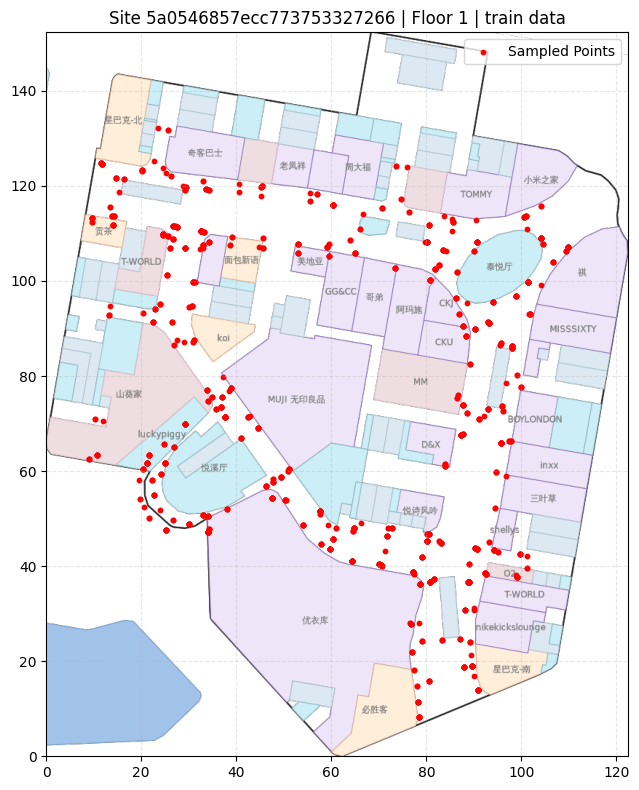

In [7]:

plot_floor_points_from_wifi_csv(
    site=site,
    floor=floor,
    wifi_root=wifi_root,
    metadata_root=metadata_root,
    split="train",
    sample=1000
)


find the white area inside the blace line

In [ ]:
import cv2
import numpy as np
import json
from pathlib import Path

def draw_white_border_red_from_metadata(
    site,
    floor,
    metadata_root,
    *,
    red_thickness=4,
    white_S_max=40,     # how “pure” white must be (increase to include slightly colored whites)
    white_V_min=50,    # how bright white must be (lower if whites are dim)
    black_V_max=10 ,     # how dark the black border is (raise if walls are grayish)
    min_white_area_px=10,  # ignore tiny white specks
    shrink_white_px=0,      # shrink white a bit to avoid touching the black line
    return_masks=False
):
    """
    Loads site/floor image, detects white area INSIDE black border,
    and draws a red contour along the white area's boundary.

    Returns:
        overlay_rgb  (np.uint8 RGB image with red border drawn)
        (optionally: dict of masks)
    """
    # --- locate and load image + metadata
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    floor_dir = Path(metadata_root) / site / fstr
    image_path = next(floor_dir.glob("floor_image.*"))
    img_rgb = imread(str(image_path))
    if img_rgb.dtype != np.uint8:
        img_rgb = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)
    H, W = img_rgb.shape[:2]

    # (metadata is not strictly needed here, but left for completeness)
    json_path = floor_dir / "floor_info.json"
    with open(json_path, "r") as f:
        _ = json.load(f)

    # --- HSV conversion
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # --- 1) Black border (walls/outline)
    black_lower = np.array([0, 0, 0], dtype=np.uint8)
    black_upper = np.array([180, 255, black_V_max], dtype=np.uint8)
    black_mask = cv2.inRange(hsv, black_lower, black_upper)
    black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=2)

    # --- 2) Compute interior of black border(s)
    # Take external contours and fill them to get "inside polygon"
    contours, _ = cv2.findContours(black_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    inside_polygon_mask = np.zeros((H, W), dtype=np.uint8)
    for cnt in contours:
        if cv2.contourArea(cnt) > 100:  # ignore tiny specks
            cv2.drawContours(inside_polygon_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # --- 3) White mask (low saturation, high value)
    white_lower = np.array([0, 0, white_V_min], dtype=np.uint8)
    white_upper = np.array([180, white_S_max, 255], dtype=np.uint8)
    white_mask = cv2.inRange(hsv, white_lower, white_upper)

    # --- 4) White strictly inside polygon (exclude the black line itself)
    white_inside = cv2.bitwise_and(white_mask, inside_polygon_mask)
    white_inside = cv2.bitwise_and(white_inside, cv2.bitwise_not(black_mask))

    # Remove tiny noise
    white_inside = cv2.morphologyEx(white_inside, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

    # Optional: shrink a touch so the drawn red line stays inside the black border visually
    if shrink_white_px > 0:
        white_inside = cv2.erode(white_inside, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*shrink_white_px+1, 2*shrink_white_px+1)), iterations=1)

    # --- 5) Find white-area contours and draw them in red
    cnts, _ = cv2.findContours(white_inside, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) >= min_white_area_px]

    overlay_rgb = img_rgb.copy()
    # Draw red polylines (RGB red = (255, 0, 0))
    cv2.drawContours(overlay_rgb, cnts, contourIdx=-1, color=(255, 0, 0), thickness=red_thickness)

    if return_masks:
        return overlay_rgb, {
            "black_mask": black_mask,
            "inside_polygon_mask": inside_polygon_mask,
            "white_mask": white_mask,
            "white_inside": white_inside
        }
    return overlay_rgb


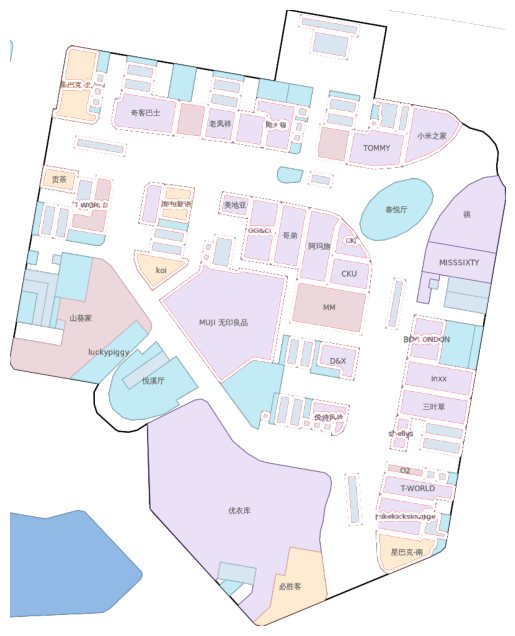

In [53]:
overlay = draw_white_border_red_from_metadata(
    site=site,
    floor=floor,
    metadata_root=metadata_root,
    red_thickness=3,
    white_S_max=45,
    white_V_min=205,
    black_V_max=90,
    shrink_white_px=1
)

# Quick view (matplotlib uses RGB)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis('off')
plt.show()




In [55]:
import cv2
import numpy as np
import json
from pathlib import Path

def draw_lightareas_border_red_from_metadata(
    site,
    floor,
    metadata_root,
    *,
    red_thickness=4,

    # --- black outline detection ---
    black_V_max=90,       # raise if the walls are grayish
    close_iters=3,        # close small gaps in the outline

    # --- "white / light pastel" gate (keeps light areas even if slightly tinted)
    white_S_max=70,       # allow some saturation so pastels pass
    white_V_min=190,      # brightness for "light"
    
    # --- explicit hue ranges to add blue & purple rooms ---
    blue_H_range=(95, 130),     # OpenCV H in [0,180]
    blue_S_min=40, blue_V_min=120,
    purple_H_range=(130, 165),
    purple_S_min=30, purple_V_min=110,

    min_area_px=80,
    shrink_px=1,          # shrink interior 1px so red line won't sit on the wall
    return_masks=False
):
    """
    Detects light/white, blue, and purple regions inside the black border and
    draws a red contour along their outer boundary (union of those regions).
    """
    # --- locate and load image ---
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    floor_dir = Path(metadata_root) / site / fstr
    image_path = next(floor_dir.glob("floor_image.*"))
    img_rgb = imread(str(image_path))
    if img_rgb.dtype != np.uint8:
        img_rgb = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)

    H, W = img_rgb.shape[:2]
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # --- 1) Black border mask ---
    black_mask = cv2.inRange(
        hsv, np.array([0, 0, 0], np.uint8),
             np.array([180, 255, black_V_max], np.uint8)
    )
    kernel3 = np.ones((3,3), np.uint8)
    black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_CLOSE, kernel3, iterations=close_iters)

    # --- 2) Inside of the outline (fill external contours) ---
    contours, _ = cv2.findContours(black_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    inside_polygon_mask = np.zeros((H, W), dtype=np.uint8)
    for cnt in contours:
        if cv2.contourArea(cnt) > 100:
            cv2.drawContours(inside_polygon_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # --- 3) White / light pastel mask ---
    white_mask = cv2.inRange(
        hsv,
        np.array([0, 0, white_V_min], np.uint8),
        np.array([180, white_S_max, 255], np.uint8)
    )

    # --- 4) Explicit blue & purple masks (to catch those rooms robustly) ---
    h_lo, h_hi = blue_H_range
    blue_mask = cv2.inRange(
        hsv,
        np.array([h_lo, blue_S_min, blue_V_min], np.uint8),
        np.array([h_hi, 255, 255], np.uint8)
    )
    h_lo, h_hi = purple_H_range
    purple_mask = cv2.inRange(
        hsv,
        np.array([h_lo, purple_S_min, purple_V_min], np.uint8),
        np.array([h_hi, 255, 255], np.uint8)
    )

    # --- 5) Union of target regions, strictly INSIDE, excluding the wall itself ---
    target = cv2.bitwise_or(white_mask, blue_mask)
    target = cv2.bitwise_or(target, purple_mask)
    target = cv2.bitwise_and(target, inside_polygon_mask)
    target = cv2.bitwise_and(target, cv2.bitwise_not(black_mask))

    # clean + slight shrink so the red line is visually inside the wall
    target = cv2.morphologyEx(target, cv2.MORPH_OPEN, kernel3, iterations=1)
    if shrink_px > 0:
        k = 2*shrink_px+1
        target = cv2.erode(target, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # --- 6) Draw the outer boundary of all selected regions ---
    cnts, _ = cv2.findContours(target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) >= min_area_px]

    overlay = img_rgb.copy()
    cv2.drawContours(overlay, cnts, -1, (255, 0, 0), thickness=red_thickness)  # RGB red

    if return_masks:
        return overlay, {
            "black_mask": black_mask,
            "inside_polygon_mask": inside_polygon_mask,
            "white_mask": white_mask,
            "blue_mask": blue_mask,
            "purple_mask": purple_mask,
            "target_union": target
        }
    return overlay


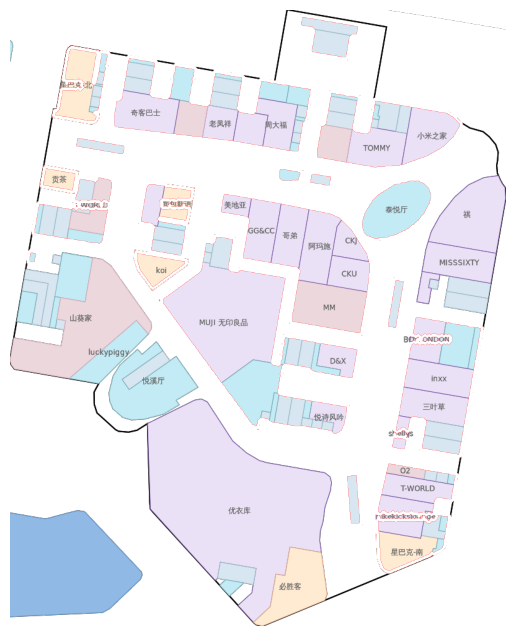

In [56]:
overlay = draw_lightareas_border_red_from_metadata(
    site=site,
    floor=floor,
    metadata_root=metadata_root,

    # Tunable params — these work well for your map
    red_thickness=4,
    black_V_max=90,
    close_iters=3,
    white_S_max=70,
    white_V_min=190,
    blue_H_range=(95, 130),
    purple_H_range=(130, 165),
    min_area_px=80,
    shrink_px=1
)

# Show the result
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis('off')
plt.show()


In [57]:
import cv2
import numpy as np
from pathlib import Path

def draw_lightareas_border_red_from_metadata_v3(
    site, floor, metadata_root,
    *,
    red_thickness=4,

    # Outline detection / robustness
    black_V_max=110,    # raise if walls are gray
    close_iters=3,
    dilate_black_px=1,

    # Classic “white / light” gate (broad)
    white_S_max=80,
    white_V_min=185,

    # Pastel gate (ANY hue, just light & low saturation)
    pastel_S_max=90,    # catch very light lavender/cyan
    pastel_V_min=165,

    # Explicit hues (widened bands)
    cyan_H=(80, 100),   cyan_S_min=25,  cyan_V_min=110,
    blue_H=(90, 140),   blue_S_min=25,  blue_V_min=110,
    purple_H=(120, 175), purple_S_min=20, purple_V_min=105,

    min_area_px=80,
    shrink_px=1,
    return_masks=False
):
    """Draw red border around union of light/white + cyan/blue/purple areas inside the black outline."""
    fstr = f"F{floor}" if not str(floor).upper().startswith("F") else str(floor).upper()
    img_path = next((Path(metadata_root)/site/fstr).glob("floor_image.*"))
    img_rgb = imread(str(img_path))
    if img_rgb.dtype != np.uint8:
        img_rgb = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)

    H, W = img_rgb.shape[:2]
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

    # --- black outline ---
    black = cv2.inRange(hsv, np.array([0,0,0], np.uint8),
                             np.array([180,255,black_V_max], np.uint8))
    black = cv2.morphologyEx(black, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=close_iters)
    if dilate_black_px > 0:
        k = 2*dilate_black_px+1
        black = cv2.dilate(black, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    # --- compute inside via flood-fill from edges ---
    ff_src = (black == 0).astype(np.uint8) * 255
    ff = np.pad(ff_src, ((1,1),(1,1)), mode="constant")
    mask_ff = np.zeros((ff.shape[0]+2, ff.shape[1]+2), np.uint8)
    for seed in [(1,1), (ff.shape[1]-2,1), (1,ff.shape[0]-2), (ff.shape[1]-2,ff.shape[0]-2)]:
        cv2.floodFill(ff, mask_ff, seed, 128)
    outside = (ff[1:-1,1:-1] == 128).astype(np.uint8) * 255
    inside  = cv2.bitwise_and(cv2.bitwise_not(outside), cv2.bitwise_not(black))

    # --- gates ---
    # 1) broad white/light
    white = cv2.inRange(hsv, np.array([0,0,white_V_min], np.uint8),
                             np.array([180,white_S_max,255], np.uint8))
    # 2) pastel (any hue): low S, high V
    s = hsv[...,1]; v = hsv[...,2]
    pastel = np.zeros((H,W), np.uint8)
    pastel[(s <= pastel_S_max) & (v >= pastel_V_min)] = 255

    # 3) explicit cyan / blue / purple (wider)
    def hue_mask(h_lo, h_hi, s_min, v_min):
        return cv2.inRange(hsv,
                           np.array([h_lo, s_min, v_min], np.uint8),
                           np.array([h_hi, 255, 255], np.uint8))
    cyan   = hue_mask(*cyan_H,   cyan_S_min,   cyan_V_min)
    blue   = hue_mask(*blue_H,   blue_S_min,   blue_V_min)
    purple = hue_mask(*purple_H, purple_S_min, purple_V_min)

    # union, constrained to inside, excluding walls
    target = white | pastel | cyan | blue | purple
    target = cv2.bitwise_and(target, inside)
    target = cv2.bitwise_and(target, cv2.bitwise_not(black))

    # clean & shrink slightly so line stays off the wall
    target = cv2.morphologyEx(target, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), 1)
    if shrink_px > 0:
        k = 2*shrink_px+1
        target = cv2.erode(target, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k)), 1)

    cnts, _ = cv2.findContours(target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = [c for c in cnts if cv2.contourArea(c) >= min_area_px]

    overlay = img_rgb.copy()
    cv2.drawContours(overlay, cnts, -1, (255,0,0), thickness=red_thickness)

    if return_masks:
        return overlay, {
            "black": black, "inside": inside,
            "white": white, "pastel": pastel,
            "cyan": cyan, "blue": blue, "purple": purple,
            "target": target
        }
    return overlay


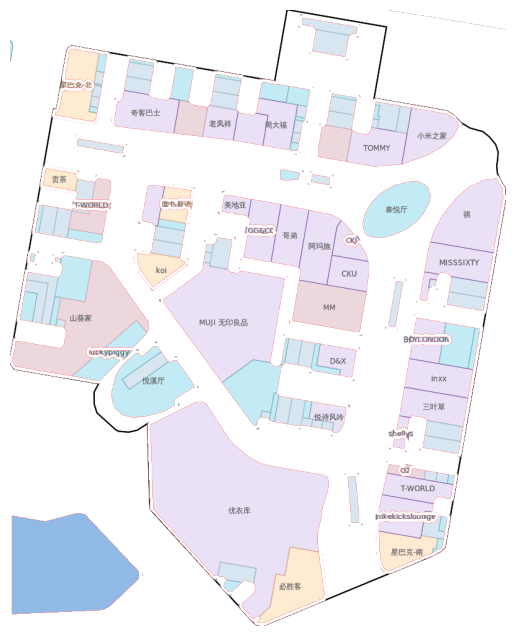

In [58]:
overlay = draw_lightareas_border_red_from_metadata_v3(
    site=site, floor=floor, metadata_root=metadata_root,
    red_thickness=4,
    black_V_max=110, close_iters=3, dilate_black_px=1,
    white_S_max=80, white_V_min=185,
    pastel_S_max=90, pastel_V_min=165,
    cyan_H=(80,100), blue_H=(90,140), purple_H=(120,175),
    min_area_px=80, shrink_px=1
)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.imshow(overlay); plt.axis('off'); plt.show()
